# 1. Import and Hardware Setup

In [54]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

!pip install tqdm -q
from tqdm.auto import tqdm

!pip install wandb -q
import wandb

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [56]:
DATA_PATH = './Data'
SAVE_PATH = './Model'

In [57]:
# Login Weight & Bias
wandb.login()

wandb: WARNING Unable to verify login in offline mode.


False

# 2. Hyperparameters

In [58]:
BATCH_SIZE = 128
IMG_SIZE = 227
IMG_CHANNELS = 3
NUM_CLASSES = 101

EPOCHS = 10
LR = 0.01
DROPOUT_RATE = 0.5

SEED = 42

# 3. Dataset Preparation

In [59]:
stats = ((0.545, 0.443, 0.344), (0.269, 0.271, 0.276))

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(227),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [60]:
import os
import numpy as np
import random

def set_seed(seed: int = 42):
    # Set the environment variable PYTHONHASHSEED to the string
    # representation of seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Seeds
    random.seed(seed) # Python's built-in random module RNG
    np.random.seed(seed) # Numpy's global RNG
    torch.manual_seed(seed) # PyTorch CPU RNG
    torch.cuda.manual_seed_all(seed) # PyTorch CUDA RNG
    
    # Requests deterministic algorithms for cuDNN where possible
    torch.backends.cudnn.deterministic = True

    # Disables cuDNN autotuner that picks the fastest convolution
    # algorithm per-input-size
    torch.backends.cudnn.benchmark = False

    # Keep determinism enabled, but do not crash on unsupported CUDA ops.
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

set_seed(SEED)

In [61]:
# Load the full train data
dummy_data = datasets.Food101(root=DATA_PATH, download=True, split="train")

# Split the full train data into train and validation data
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)

train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

# Extract indices and create subset with correct transform
train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

train_dataset = datasets.Food101(
    root=DATA_PATH, download=False, split="train", transform=train_transform
)
val_dataset = datasets.Food101(
    root=DATA_PATH, download=False, split='train', transform=test_transform
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Load Test Dataset
test_dataset = datasets.Food101(
    root=DATA_PATH, download=True, split="test", transform=test_transform
)

In [62]:
def seed_worker(worker_id):
    # Use the worker-specific seed set by DataLoader's generator
    # torch.initial_seed() return a 64-bit seed, reduce to 32 bit
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)
    
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

# Loader
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, persistent_workers=True,
                        worker_init_fn=seed_worker, generator=train_generator)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, persistent_workers=True,
                        worker_init_fn=seed_worker, generator=eval_generator)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, persistent_workers=True,
                        worker_init_fn=seed_worker, generator=eval_generator)


# 4. AlexNet Architecture

![AlexNet](AlexNet.png)

In [63]:
class AlexNet(nn.Module):
    def __init__(self, img_size, in_channels, num_classes, dropout_rate):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            # Conv 1: 227x227 -> 55x55
            nn.Conv2d(in_channels, 96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),

            # MaxPool 1: 55x55 -> 27x27
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv 2: 27x27 -> 27x27
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),

            # MaxPool 2: 27x27 -> 13x13
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv 3: 13x13 -> 13x13
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv 4: 13x13 -> 13x13
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv 5: 13x13 -> 13x13
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # MaxPool 3: 13x13 -> 6x6
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(9216, 4096), # 6x6x256 = 9216 -> 4096
            nn.ReLU(inplace=True),

            nn.Dropout(dropout_rate),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        # Paper-like init: weights ~ N(0, 0.01), most biases = 0
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

        # Bias = 1 for Conv2, Conv4, Conv5 and first two FC layers
        nn.init.constant_(self.feature_extractor[4].bias, 1.0)   # Conv2
        nn.init.constant_(self.feature_extractor[10].bias, 1.0)  # Conv4
        nn.init.constant_(self.feature_extractor[12].bias, 1.0)  # Conv5
        nn.init.constant_(self.classifier[1].bias, 1.0)          # FC6
        nn.init.constant_(self.classifier[4].bias, 1.0)          # FC7

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)

        return logits

In [64]:
model = AlexNet(IMG_SIZE, IMG_CHANNELS, NUM_CLASSES, DROPOUT_RATE).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiples GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Total parameters: 58.70M
Using 2 GPUs


# 5. Training

In [65]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        self.early_stop = False
        self.counter = 0
        self.verbose = False
        self.best_loss = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print('Saving best checkpoint ...')
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [66]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.1)

# Using GradScaler to prevent Gradient Underflow when using FP16
scaler = torch.amp.GradScaler(device)

In [67]:
def train(model, loader, criterion, optimizer, scaler):
    # Set the model into train mode
    model.train()
    
    # Define the loss and acc
    train_loss, correct = 0, 0

    # Create Loading Progress with
    loop = tqdm(loader, desc="Training", leave=False)

    # Loop through the loop
    for x, y in loop:
        # Move training data to device
        x, y = x.to(device), y.to(device)

        # Clear the gradients of last batch, set to None to save memory
        optimizer.zero_grad(set_to_none=True)

        # 
        with torch.amp.autocast(device_type=device.type):
            # get the prediction
            out = model(x)
            # Calculate loss
            loss = criterion(out, y)

        # Scaling the loss -> Backpropagation
        scaler.scale(loss).backward()
        # scaler.scale(loss): multiplies the loss by a larger "scale factor"
        # -> The loss becomes larger, moving them out of the "underflow zone"
        # .backward(): performs the standard backpropagation

        # Unscale before clipping
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Unscale the gradients before the optimizer updates the weights
        scaler.step(optimizer)

        # Adjusts the scale factor for the next batch
        scaler.update()

        train_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()

    return train_loss / len(loader.dataset), correct / len(loader.dataset)

In [68]:
def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0, 0

    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item() * x.size(0)
            val_acc += (out.argmax(1) == y).sum().item()

    return val_loss / len(loader.dataset), val_acc / len(loader.dataset)

In [69]:
def evaluate(model, loader):
    model.eval()
    eval_acc = 0

    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)

            eval_acc += (out.argmax(1) == y).sum().item()

    return eval_acc / len(loader.dataset)

In [70]:
wandb.init(
    project = "AlexNet",
    config = {
        "Architecture": "AlexNet",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE
    }
)

train_accuracies, val_accuracies = [], []
train_losses, test_losses = [], []
early_stopping = EarlyStopping(patience=6)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)
    
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_losses.append(train_loss)
    test_losses.append(val_loss)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": val_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    print(f"{epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}," +
                             f" train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = evaluate(model, test_loader)
print(f"Final accuracy: {test_acc:.4f}")

wandb.log({"test_acc": test_acc})
wandb.finish()

Training:   0%|          | 0/474 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: avg_pool3d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Validation:   0%|          | 0/119 [00:00<?, ?it/s]

1/10: train_loss: 4.7686, val_loss: 4.6489, train_acc: 0.0092, val_acc: 0.0095


Training:   0%|          | 0/474 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

10/10: train_loss: 4.6156, val_loss: 4.6165, train_acc: 0.0103, val_acc: 0.0081
Early Stopping counter: 4 out of 6


Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Final accuracy: 0.0099


epoch,▁▂▃▃▄▅▆▆▇█
lr,█████████▁
test_acc,▅▅▃▅▃▃▆█▁▁▆
train_acc,▁▄██▇▄▅▅▃█
train_loss,█▂▁▁▁▁▁▁▁▁
val_acc,▅▅▃▅▃▃▆█▁▁
val_loss,█▁▁▁▁▁▁▁▁▁
epoch,10
lr,0.001
test_acc,0.0099
train_acc,0.01028


# 6. Result Plot

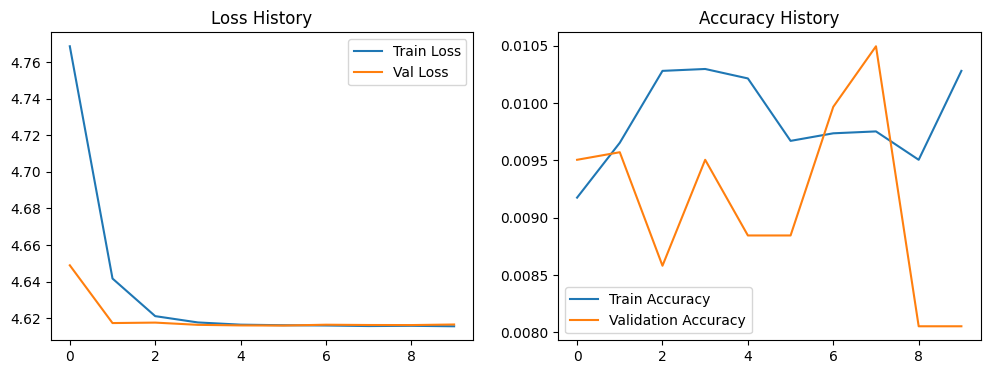

In [71]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Val Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy History')
plt.legend()

# 7. Heatmap with Grad-CAM

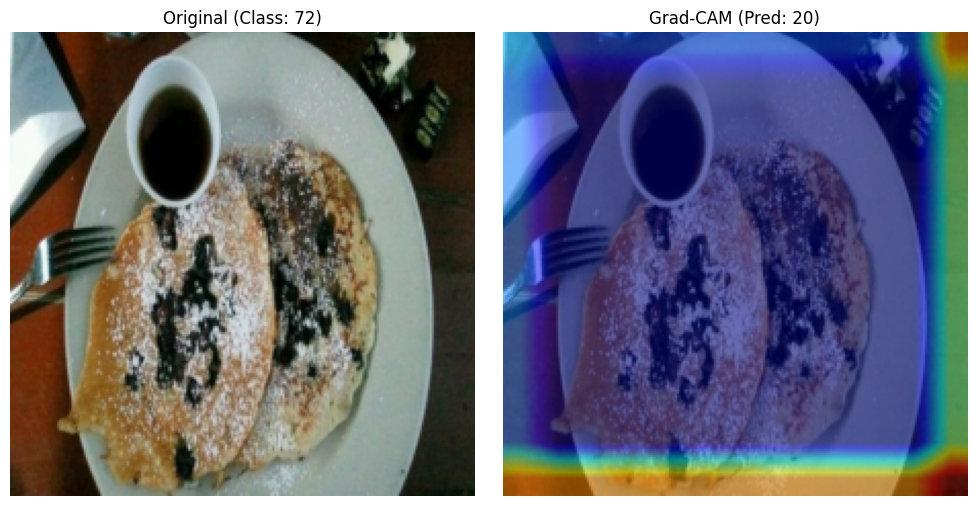

In [72]:
!pip install grad-cam -q
import torchvision.transforms.functional as F_vision
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import random

# 1. Setup the Grad-CAM object
# Unwrap DataParallel if needed
cam_model = model.module if hasattr(model, 'module') else model
# AlexNet's last conv layer is the 3rd-to-last element in feature_extractor
target_layers = [cam_model.feature_extractor[-3]]
cam = GradCAM(model=cam_model, target_layers=target_layers)

# 2. Pick a random image from the test set
imgs, labels = next(iter(test_loader))
indx = random.randint(0, len(imgs) - 1)
input_tensor = imgs[indx].unsqueeze(0).to(device)
label = labels[indx].item()

# 3. Generate the Grad-CAM heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=None)
grayscale_cam = grayscale_cam[0, :]

# 4. Prepare the image for Visualization
mean = torch.tensor(stats[0]).view(3, 1, 1)
std = torch.tensor(stats[1]).view(3, 1, 1)
rgb_img = imgs[indx] * std + mean # Denormalize
rgb_img = rgb_img.permute(1, 2, 0).numpy()
rgb_img = np.clip(rgb_img, 0, 1)

# 5. Overlay the heatmap on the image
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 6. Get the Prediction
cam_model.eval()
with torch.no_grad():
    output = cam_model(input_tensor)
    pred = output.argmax(1).item()

# 7. Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original (Class: {label})")
plt.imshow(rgb_img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title(f"Grad-CAM (Pred: {pred})")
plt.imshow(visualization)
plt.axis('off')
plt.tight_layout()
plt.show()